# 14 Entity Type Analysis

Purpose:
- isolate the entity-type story from the broader alignment notebooks
- quantify where human priors and model priors are aligned vs divergent
- produce export tables for the supplement

Primary questions:
1. Which entity types are most aligned between humans and model groups?
2. Do entity types differ in blind accuracy, semantic agreement, or bias signatures?
3. How do entity types degrade across control variants `C -> B -> A`?
4. Which entity types are most instruction-sensitive?


In [1]:
from __future__ import annotations

import csv
import math
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE = Path('/home/david/Desktop/yuna/HPA')
sys.path.insert(0, str(BASE / 'analysis'))
sys.path.insert(0, str(BASE))

from utils.constants import GROUP_COLORS, VARIANT_LABELS, VARIANT_ORDER

EXPORTS = BASE / 'analysis/session2/exports'
FIG_DIR = BASE / 'latex/AnonymousSubmission/LaTeX/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
(FIG_DIR / 'entity_analysis').mkdir(parents=True, exist_ok=True)

sns.set_context('talk')
sns.set_style('whitegrid')

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)


In [2]:
human = pd.read_csv(EXPORTS / 'responses_human.csv')
model_blind = pd.read_csv(EXPORTS / 'responses_model_blind.csv')
model_inst = pd.read_csv(EXPORTS / 'responses_model_inst_blind.csv')
model_ctrl = pd.read_csv(EXPORTS / 'responses_model_control.csv')
pair_df = pd.read_parquet(EXPORTS / 'pair_cache.parquet')
combined = pd.read_parquet(EXPORTS / 'combined_agreement.parquet')

human.head(2)
q_meta = (human[['question_id', 'ent', 'op', 'question_en']]
    .drop_duplicates(subset=['question_id'])
)

## Helpers

In [3]:
from figures.helpers import save_fig
def pearson_safe(x, y):
    x = np.asarray(list(x), dtype=float)
    y = np.asarray(list(y), dtype=float)
    if len(x) < 2 or len(y) < 2:
        return np.nan
    if np.allclose(x, x.mean()) or np.allclose(y, y.mean()):
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def summarize_question_accuracy(df, who='model'):
    group_cols = ['question_id', 'ent', 'op', 'variant']
    if who == 'model':
        group_cols += ['model_group', 'model']
    out = (df.groupby(group_cols, dropna=False)['accuracy']
             .mean()
             .reset_index())
    out = out.rename(columns={'accuracy': f'{who}_acc'})
    return out


def export_csv(df, name):
    path = EXPORTS / name
    df.to_csv(path, index=False)
    print(f'saved: {path}')
    return path


def sort_entities(df, ent_col='ent'):
    order = ent_counts.sort_values('n_questions', ascending=False)['ent'].tolist()
    out = df.copy()
    out[ent_col] = pd.Categorical(out[ent_col], categories=order, ordered=True)
    return out.sort_values(ent_col)


## 1. Entity coverage

In [4]:
ent_counts = (human[human['variant'] == 'C'][['question_id', 'ent']]
              .drop_duplicates()['ent']
              .value_counts()
              .rename_axis('ent')
              .reset_index(name='n_questions'))
ent_counts

,ent,n_questions
0,object,27
1,person,26
2,animal,17
3,food,16
4,other,9
5,product,5
6,place,5
7,vehicle,4
8,text,4


## 2. Accuracy by entity type

In [5]:
human_q = summarize_question_accuracy(human, who='human')
blind_q = summarize_question_accuracy(model_blind, who='model')
inst_q = summarize_question_accuracy(model_inst, who='model')
ctrl_q = summarize_question_accuracy(model_ctrl, who='model')

human_ent_acc = (human_q.groupby(['ent', 'variant'], dropna=False)['human_acc']
                 .mean()
                 .reset_index())

model_ent_acc = (inst_q.groupby(['model_group', 'ent', 'variant'], dropna=False)['model_acc']
                 .mean()
                 .reset_index())

entity_accuracy_summary = (model_ent_acc
    .merge(human_ent_acc, on=['ent', 'variant'], how='left')
    .merge(ent_counts, on='ent', how='left')
    .sort_values(['variant', 'ent', 'model_group']))

entity_accuracy_summary.head(20)

,model_group,ent,variant,model_acc,human_acc,n_questions
0,VLM,animal,A,0.360071,0.313725,17
27,VLM backbone decoder,animal,A,0.358289,0.313725,17
54,standalone LLM,animal,A,0.169591,0.313725,17
81,standalone LLM (think),animal,A,0.141176,0.313725,17
3,VLM,food,A,0.392045,0.317708,16
30,VLM backbone decoder,food,A,0.384470,0.317708,16
57,standalone LLM,food,A,0.220833,0.317708,16
84,standalone LLM (think),food,A,0.166667,0.317708,16
6,VLM,object,A,0.383838,0.146914,27
33,VLM backbone decoder,object,A,0.202020,0.146914,27


## 3. Human-model difficulty correlation by entity type

In [6]:
merged_inst = inst_q.merge(
    human_q[['question_id', 'ent', 'op', 'variant', 'human_acc']],
    on=['question_id', 'ent', 'op', 'variant'],
    how='left'
)

corr_rows = []
for (model_group, ent, variant), sub in merged_inst.groupby(['model_group', 'ent', 'variant'], dropna=False):
    corr_rows.append({
        'model_group': model_group,
        'ent': ent,
        'variant': variant,
        'n_questions': sub['question_id'].nunique(),
        'pearson_r': pearson_safe(sub['human_acc'], sub['model_acc']),
        'human_mean_acc': sub['human_acc'].mean(),
        'model_mean_acc': sub['model_acc'].mean(),
    })

entity_corr = pd.DataFrame(corr_rows).sort_values(['variant', 'model_group', 'pearson_r'], ascending=[True, True, False])
entity_corr.head(30)

,model_group,ent,variant,n_questions,pearson_r,human_mean_acc,model_mean_acc
0,VLM,animal,A,17,0.874578,0.313725,0.360071
24,VLM,vehicle,A,4,0.756023,0.212500,0.295455
3,VLM,food,A,16,0.629086,0.317708,0.392045
9,VLM,other,A,9,0.574792,0.248148,0.380471
15,VLM,place,A,5,0.485618,0.408333,0.430303
12,VLM,person,A,26,0.380177,0.199038,0.357809
6,VLM,object,A,27,0.159218,0.146914,0.383838
18,VLM,product,A,5,-0.119124,0.141667,0.163636
21,VLM,text,A,4,NaN,0.000000,0.000000
51,VLM backbone decoder,vehicle,A,4,0.932094,0.212500,0.333333


## 4. Semantic agreement by entity type

Use HM pairwise agreement from the pair cache. This is the main evidence for
which model groups recover human priors at the meaning level.

In [7]:
hm_pairs = pair_df[(pair_df['pair_type'] == 'HM') & (pair_df['variant'].isin(VARIANT_ORDER))].copy()

entity_semantic = (hm_pairs.groupby(['subject_group_2', 'ent', 'variant'], dropna=False)
    .agg(
        sbert=('sbert_score_clip', 'mean'),
        simcse=('simcse_score_clip', 'mean'),
        bertscore=('bertscore_f1', 'mean'),
        exact=('exact_score', 'mean'),
        chrf=('chrf_score', 'mean'),
        n_pairs=('question_id', 'size'),
        n_questions=('question_id', 'nunique'),
    )
    .reset_index()
    .rename(columns={'subject_group_2': 'model_group'})
    .sort_values(['variant', 'ent', 'sbert'], ascending=[True, True, False]))

entity_semantic.head(30)

,model_group,ent,variant,sbert,simcse,bertscore,exact,chrf,n_pairs,n_questions
27,VLM backbone decoder,animal,A,0.460415,0.530687,0.942028,0.106818,0.150038,5280,12
0,VLM,animal,A,0.434236,0.501951,0.943186,0.095265,0.132420,5280,12
81,standalone LLM (think),animal,A,0.364298,0.481789,0.896005,0.068333,0.101362,2400,12
54,standalone LLM,animal,A,0.348392,0.479275,0.891242,0.057292,0.092384,4800,12
30,VLM backbone decoder,food,A,0.450178,0.531864,0.925242,0.058471,0.109442,4840,11
3,VLM,food,A,0.409083,0.487920,0.934865,0.041736,0.083479,4840,11
84,standalone LLM (think),food,A,0.366573,0.497471,0.878813,0.039091,0.069745,2200,11
57,standalone LLM,food,A,0.366311,0.507167,0.899111,0.037955,0.081627,4400,11
33,VLM backbone decoder,object,A,0.458171,0.543443,0.942930,0.079941,0.118437,10120,23
6,VLM,object,A,0.443368,0.526641,0.956403,0.057905,0.092629,10120,23


## 4a. Main-paper candidate: Pearson r by entity type

Compare `VLM` vs `VLM backbone decoder` on variant `C` only. This is the cleanest
entity-type view for the paper because it directly supports the main model-group claim.

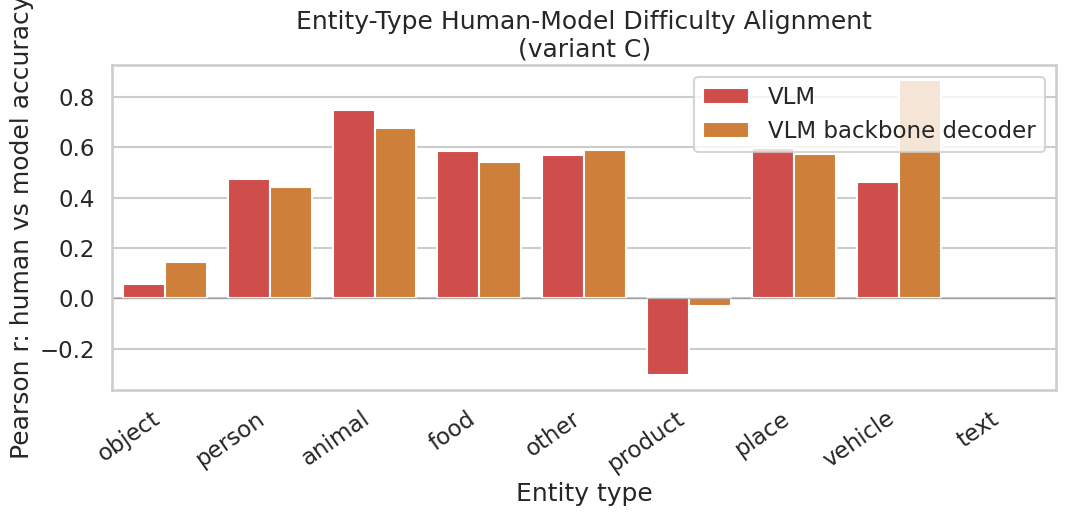

In [8]:
corr_plot = entity_corr[
    (entity_corr['variant'] == 'C')
    & (entity_corr['model_group'].isin(['VLM', 'VLM backbone decoder']))
    & (entity_corr['n_questions'] >= 3)
].copy()
corr_plot = sort_entities(corr_plot)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(
    data=corr_plot,
    x='ent', y='pearson_r', hue='model_group',
    palette={k: GROUP_COLORS[k] for k in ['VLM', 'VLM backbone decoder']},
    ax=ax
)
ax.axhline(0, color='gray', lw=1, alpha=0.6)
ax.set_xlabel('Entity type')
ax.set_ylabel('Pearson r: human vs model accuracy')
ax.set_title('Entity-Type Human-Model Difficulty Alignment\n(variant C)')
ax.legend(title=None, frameon=True, loc='upper right')
for tick in ax.get_xticklabels():
    tick.set_rotation(35)
    tick.set_horizontalalignment('right')
plt.tight_layout()

## 4b. Main-paper candidate: semantic agreement by entity type

This focuses on `HM` SBERT agreement, which is the main semantic metric for
human-prior similarity.

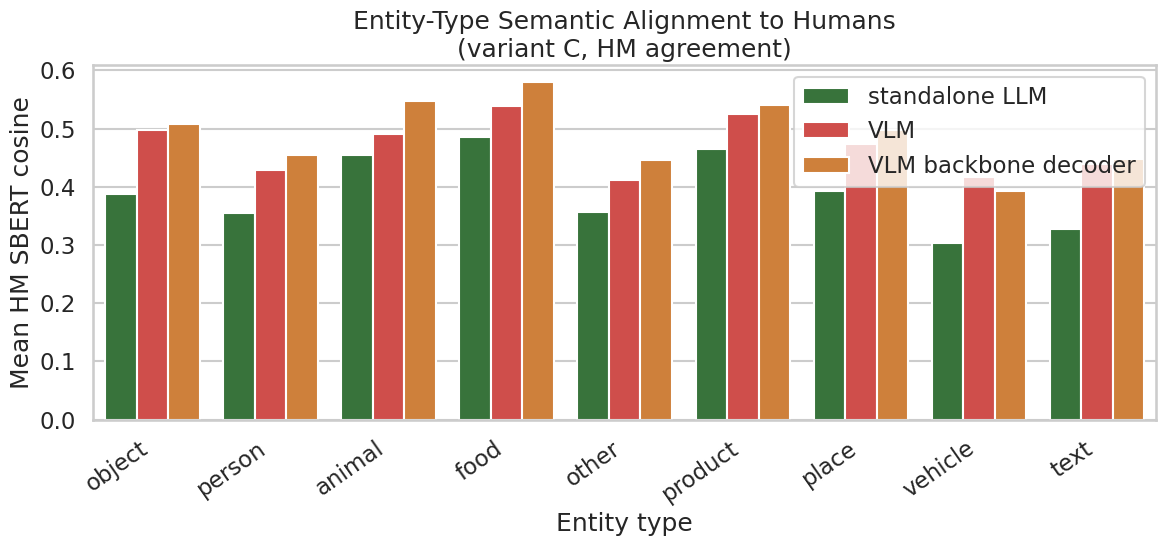

In [9]:
sem_plot = entity_semantic[
    (entity_semantic['variant'] == 'C')
    & (entity_semantic['model_group'].isin(['VLM', 'VLM backbone decoder', 'standalone LLM']))
    & (entity_semantic['n_questions'] >= 3)
].copy()
sem_plot = sort_entities(sem_plot)

fig, ax = plt.subplots(figsize=(12, 5.8))
sns.barplot(
    data=sem_plot,
    x='ent', y='sbert', hue='model_group',
    palette={k: GROUP_COLORS[k] for k in ['VLM', 'VLM backbone decoder', 'standalone LLM']},
    ax=ax
)
ax.set_xlabel('Entity type')
ax.set_ylabel('Mean HM SBERT cosine')
ax.set_title('Entity-Type Semantic Alignment to Humans\n(variant C, HM agreement)')
ax.legend(title=None, frameon=True, loc='upper right')
for tick in ax.get_xticklabels():
    tick.set_rotation(35)
    tick.set_horizontalalignment('right')
plt.tight_layout()

## 4c. HM SBERT by entity type with HH baseline

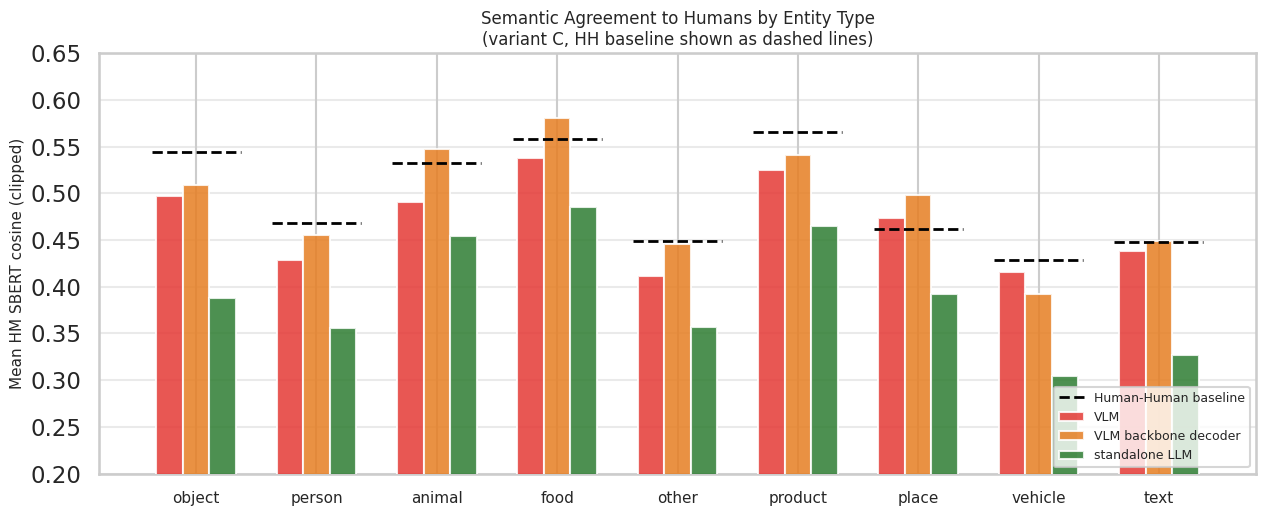

In [10]:

# HH baseline by entity type (variant C only, clipped score to match HM)
hh_pairs = pair_df[(pair_df['pair_type'] == 'HH') & (pair_df['variant'] == 'C')]
hh_ent_baseline = (hh_pairs.groupby('ent')['sbert_score_clip']
                   .mean()
                   .reset_index()
                   .rename(columns={'sbert_score_clip': 'hh_sbert'}))

groups_to_plot = ['VLM', 'VLM backbone decoder', 'standalone LLM']
sem_c = entity_semantic[
    (entity_semantic['variant'] == 'C')
    & (entity_semantic['model_group'].isin(groups_to_plot))
    & (entity_semantic['n_questions'] >= 3)
].copy()
sem_c = sort_entities(sem_c)

ent_order = sem_c['ent'].cat.categories.tolist()
hh_ent_baseline = hh_ent_baseline.set_index('ent').reindex(ent_order)

x = np.arange(len(ent_order))
n = len(groups_to_plot)
width = 0.22
offsets = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * width

fig, ax = plt.subplots(figsize=(13, 5.5))

for i, grp in enumerate(groups_to_plot):
    vals = sem_c[sem_c['model_group'] == grp].set_index('ent').reindex(ent_order)['sbert'].values
    ax.bar(x + offsets[i], vals, width=width, label=grp,
           color=GROUP_COLORS[grp], alpha=0.85, zorder=3)

# HH baseline: dashed line spanning each group's bar cluster
half_span = (n / 2) * width + 0.04
for xi, ent in zip(x, ent_order):
    hval = hh_ent_baseline.loc[ent, 'hh_sbert'] if ent in hh_ent_baseline.index else np.nan
    if not np.isnan(hval):
        ax.hlines(hval, xi - half_span, xi + half_span,
                  colors='black', lw=2, ls='--', zorder=5)

ax.hlines([], [], [], colors='black', lw=2, ls='--', label='Human-Human baseline')

ax.set_xticks(x)
ax.set_xticklabels(ent_order, fontsize=11)
ax.set_ylabel('Mean HM SBERT cosine (clipped)', fontsize=11)
ax.set_title('Semantic Agreement to Humans by Entity Type\n(variant C, HH baseline shown as dashed lines)', fontsize=12)
ax.legend(fontsize=9, loc='lower right', frameon=True)
ax.set_ylim(0.20, 0.65)
ax.yaxis.grid(True, alpha=0.4, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 5. Control-variant degradation by entity type

In [11]:
ctrl_ent = (ctrl_q.groupby(['model_group', 'ent', 'variant'], dropna=False)['model_acc']
            .mean()
            .reset_index())

human_ctrl_ent = (human_q.groupby(['ent', 'variant'], dropna=False)['human_acc']
                  .mean()
                  .reset_index())

ctrl_pivot = ctrl_ent.pivot_table(index=['model_group', 'ent'], columns='variant', values='model_acc')
for col in ['A', 'B', 'C']:
    if col not in ctrl_pivot.columns:
        ctrl_pivot[col] = np.nan
ctrl_pivot = ctrl_pivot.reset_index()
ctrl_pivot['drop_C_to_A'] = ctrl_pivot['C'] - ctrl_pivot['A']
ctrl_pivot['drop_C_to_B'] = ctrl_pivot['C'] - ctrl_pivot['B']
ctrl_pivot.sort_values('drop_C_to_A', ascending=False).head(20)

variant,model_group,ent,A,B,C,drop_C_to_A,drop_C_to_B
5,VLM,place,0.584906,0.833333,0.842105,2.571996e-01,0.008772
2,VLM,object,0.472706,0.570261,0.673333,2.006272e-01,0.103072
3,VLM,other,0.422680,0.523148,0.571429,1.487482e-01,0.048280
6,VLM,product,0.660494,0.763158,0.777778,1.172840e-01,0.014620
8,VLM,vehicle,0.420635,0.440860,0.537634,1.169995e-01,0.096774
9,VLM backbone decoder,animal,0.235294,0.294118,0.313725,7.843137e-02,0.019608
15,VLM backbone decoder,product,0.200000,0.133333,0.266667,6.666667e-02,0.133333
13,VLM backbone decoder,person,0.128205,0.179487,0.192308,6.410256e-02,0.012821
1,VLM,food,0.668639,0.663889,0.717514,4.887507e-02,0.053625
4,VLM,person,0.672794,0.609075,0.694301,2.150640e-02,0.085225


## 5a. Supplement figure: degradation heatmap by entity type

Saved: /home/david/Desktop/yuna/HPA/latex/AnonymousSubmission/LaTeX/figures/entity_analysis/fig_entity_degradation_heatmap.png


PosixPath('/home/david/Desktop/yuna/HPA/latex/AnonymousSubmission/LaTeX/figures/entity_analysis/fig_entity_degradation_heatmap.png')

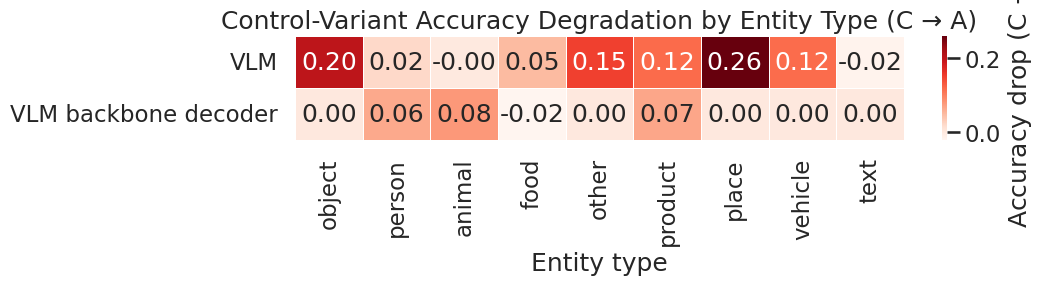

In [12]:
heat_deg = ctrl_pivot[ctrl_pivot['model_group'].isin(['VLM', 'VLM backbone decoder'])].copy()
heat_deg = sort_entities(heat_deg)

# Pivot: rows = model_group, columns = entity type
heat_arr = heat_deg.pivot_table(index='model_group', columns='ent', values='drop_C_to_A')
# Reorder rows
heat_arr = heat_arr.loc[['VLM', 'VLM backbone decoder']]

fig, ax = plt.subplots(figsize=(11, 3.2))
sns.heatmap(heat_arr, cmap='Reds', annot=True, fmt='.2f',
            cbar_kws={'label': 'Accuracy drop (C $-$ A)'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Control-Variant Accuracy Degradation by Entity Type (C → A)')
ax.set_xlabel('Entity type')
ax.set_ylabel('')
plt.tight_layout()
save_fig(fig, FIG_DIR / 'entity_analysis', 'fig_entity_degradation_heatmap.png')

## 6. Instruction sensitivity by entity type

Accuracy deltas are near-zero in the current blind vs inst_blind exports, so
the main behavioral signal here is **response change rate** by entity type.


In [13]:
blind_ent_acc = (blind_q.groupby(['model_group', 'ent', 'variant'], dropna=False)['model_acc']
                 .mean()
                 .reset_index()
                 .rename(columns={'model_acc': 'blind_acc'}))

inst_ent_acc = (inst_q.groupby(['model_group', 'ent', 'variant'], dropna=False)['model_acc']
                .mean()
                .reset_index()
                .rename(columns={'model_acc': 'inst_acc'}))

entity_instruction = blind_ent_acc.merge(inst_ent_acc, on=['model_group', 'ent', 'variant'], how='outer')
entity_instruction['delta_inst_minus_blind'] = entity_instruction['inst_acc'] - entity_instruction['blind_acc']

resp_blind = model_blind[['question_id', 'ent', 'op', 'variant', 'model', 'model_group', 'response']].copy()
resp_inst = model_inst[['question_id', 'ent', 'op', 'variant', 'model', 'model_group', 'response']].copy()
resp_merged = resp_blind.merge(
    resp_inst,
    on=['question_id', 'ent', 'op', 'variant', 'model', 'model_group'],
    suffixes=('_blind', '_inst')
)
resp_merged['resp_blind_norm'] = resp_merged['response_blind'].fillna('').astype(str).str.strip().str.lower()
resp_merged['resp_inst_norm'] = resp_merged['response_inst'].fillna('').astype(str).str.strip().str.lower()
resp_merged['response_changed'] = (resp_merged['resp_blind_norm'] != resp_merged['resp_inst_norm']).astype(float)

entity_change = (resp_merged.groupby(['model_group', 'ent', 'variant'], dropna=False)['response_changed']
                 .mean()
                 .reset_index())

entity_instruction = entity_instruction.merge(entity_change, on=['model_group', 'ent', 'variant'], how='left')
entity_instruction.sort_values(['variant', 'response_changed'], ascending=[True, False]).head(20)


,model_group,ent,variant,blind_acc,inst_acc,delta_inst_minus_blind,response_changed
102,standalone LLM (think),text,A,0.000000,0.000000,0.000000,0.842105
81,standalone LLM (think),animal,A,0.117647,0.141176,0.023529,0.764706
90,standalone LLM (think),other,A,0.111111,0.170370,0.059259,0.755556
87,standalone LLM (think),object,A,0.067669,0.076543,0.008874,0.751880
75,standalone LLM,text,A,0.016260,0.000000,-0.016260,0.750000
105,standalone LLM (think),vehicle,A,0.066667,0.083333,0.016667,0.750000
93,standalone LLM (think),person,A,0.059432,0.095607,0.036176,0.736434
72,standalone LLM,product,A,0.036364,0.019231,-0.017133,0.730769
63,standalone LLM,other,A,0.063973,0.148551,0.084578,0.695652
99,standalone LLM (think),product,A,0.040000,0.000000,-0.040000,0.680000


## 6a. Supplement figure: instruction sensitivity by entity type

Plot response change rate rather than accuracy delta, since that is the
informative behavioral effect in the current exports.


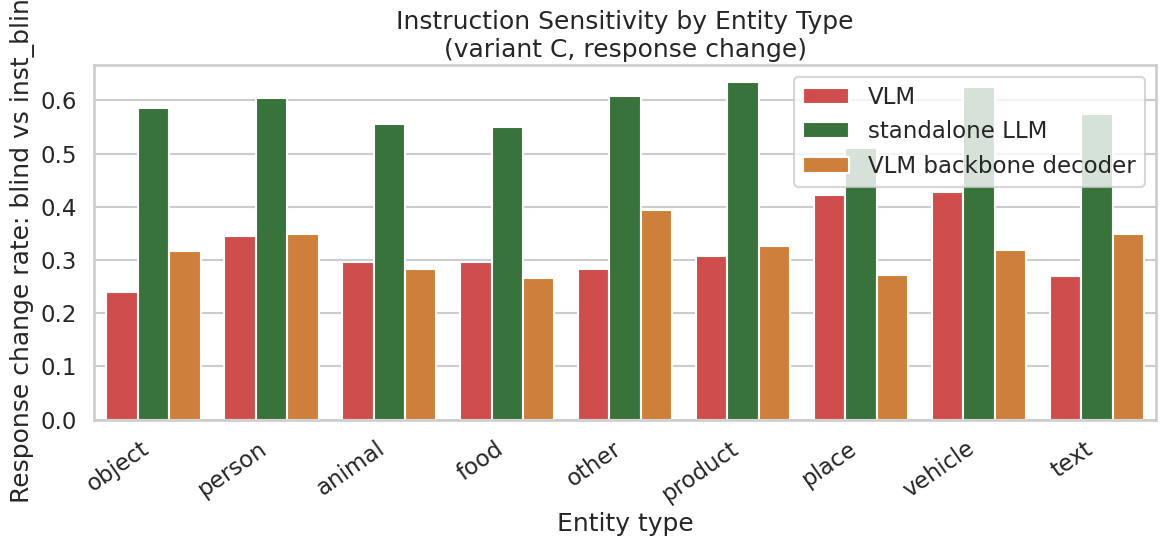

In [14]:
inst_plot = entity_instruction[
    (entity_instruction['variant'] == 'C')
    & (entity_instruction['model_group'].isin(['VLM', 'VLM backbone decoder', 'standalone LLM']))
].copy()
inst_plot = sort_entities(inst_plot)

fig, ax = plt.subplots(figsize=(12, 5.8))
sns.barplot(
    data=inst_plot,
    x='ent', y='response_changed', hue='model_group',
    palette={k: GROUP_COLORS[k] for k in ['VLM', 'VLM backbone decoder', 'standalone LLM']},
    ax=ax
)
ax.set_xlabel('Entity type')
ax.set_ylabel('Response change rate: blind vs inst_blind')
ax.set_title('Instruction Sensitivity by Entity Type\n(variant C, response change)')
ax.legend(title=None, frameon=True, loc='upper right')
for tick in ax.get_xticklabels():
    tick.set_rotation(35)
    tick.set_horizontalalignment('right')
plt.tight_layout()


## 7. Divergent example questions for the supplement

In [15]:
text_c = combined[(combined['answer_type'] == 'text') & (combined['variant'] == 'C')].copy()
text_c = text_c.merge(q_meta[['question_id', 'ent', 'op']], on='question_id', how='left')
text_c['gap_HH_HM'] = text_c['HH_sbert_score_clip'] - text_c['HM_sbert_score_clip']
entity_examples = (text_c[['question_id', 'question_en', 'ent', 'op', 'HH_sbert_score_clip', 'HM_sbert_score_clip', 'MM_sbert_score_clip', 'gap_HH_HM']]
                   .sort_values(['gap_HH_HM', 'ent'], ascending=[False, True]))
entity_examples.head(20)


,question_id,question_en,ent,op,HH_sbert_score_clip,HM_sbert_score_clip,MM_sbert_score_clip,gap_HH_HM
55,335325011,How many of these people are female?,person,count,0.716943,0.416062,0.409846,0.300881
56,344100003,How many bottles of water are on the table?,object,count,0.803880,0.516636,0.470798,0.287243
71,473110009,How many train track are there?,object,count,0.747376,0.469575,0.374881,0.277801
3,13546003,How many benches are in the background?,object,count,0.732401,0.463561,0.374257,0.268839
18,121442004,How many kids have glasses?,person,count,0.639499,0.373149,0.311266,0.266350
84,567562000,How many empty chairs are there?,object,count,0.665286,0.413678,0.387835,0.251607
49,303718006,How many bagels are here?,food,count,0.696825,0.463358,0.504078,0.233467
22,133928008,How many cranes are in this image?,object,count,0.703163,0.495980,0.586525,0.207183
80,530317001,What kind of trees are in the picture?,object,attr,0.659160,0.459849,0.534380,0.199311
86,578498007,How many shoes are under the table?,product,count,0.652859,0.458454,0.561722,0.194404


## 8. Supplement exports

In [16]:
export_csv(entity_accuracy_summary, 'entity_accuracy_summary.csv')
export_csv(entity_corr, 'entity_difficulty_correlation.csv')
export_csv(entity_semantic, 'entity_semantic_alignment.csv')
export_csv(ctrl_pivot, 'entity_control_degradation.csv')
export_csv(entity_instruction, 'entity_instruction_sensitivity.csv')
export_csv(entity_examples.head(50), 'entity_divergent_examples.csv')

saved: /home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_accuracy_summary.csv
saved: /home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_difficulty_correlation.csv
saved: /home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_semantic_alignment.csv
saved: /home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_control_degradation.csv
saved: /home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_instruction_sensitivity.csv
saved: /home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_divergent_examples.csv


PosixPath('/home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_divergent_examples.csv')

## 9. Suggested supplement figures

Main-paper candidates:
- `fig_entity_corr_groups.png`: Pearson `r` by entity type for `VLM` vs `VLM backbone decoder`
- `fig_entity_sbert_groups.png`: SBERT HM agreement by entity type across model groups

Supplement candidates:
- `fig_entity_degradation_heatmap.png`: control degradation (`drop_C_to_A`) by entity type and model group
- `fig_entity_instruction_delta.png`: instruction sensitivity by entity type and model group
- top divergent example questions per entity type
